# Testy statystyczne dla cech zbioru

Cel notebooka:
- Wczytanie i przygotowanie zbioru
- Wybór cech do testów

In [1]:
from src.data_loader import load_data
from src.preprocessing import prepare_data
from src.feature_statistical_tests import (
    compare_feature_between_classes
)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.style.use('default')  # reset stylu
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

In [2]:
# LOAD
df = load_data("../Dataset/WineQT.csv")

# BINARY MODE
X, y = prepare_data(df, mode="binary")
df = df.drop(["Id"], axis=1)

df["quality"] = y

Rozkład klas (po połączeniu klas):
quality
6    621
5    522
Name: count, dtype: int64


In [3]:
# TESTED FEATURES

features = [
    "alcohol",
    "sulphates",
    "volatile acidity"
]


===== FEATURE: alcohol =====

Class 5
count    522.000000
mean       9.922510
std        0.777469
min        8.400000
25%        9.400000
50%        9.700000
75%       10.300000
max       14.900000
Name: alcohol, dtype: float64

Class 6
count    621.000000
mean      10.878878
std        1.109438
min        8.400000
25%       10.000000
50%       10.800000
75%       11.700000
max       14.000000
Name: alcohol, dtype: float64

===== SHAPIRO-WILK =====
Class 5: stat=0.8514, p=0.000000
Class 6: stat=0.9775, p=0.000000

===== LEVENE =====
stat=98.0234, p=0.000000

===== WELCH T-TEST =====
stat=-17.0671, p=0.000000

===== MANN-WHITNEY U =====
stat=76137.0000, p=0.000000

===== CONFIDENCE INTERVAL =====
Mean difference: -0.9564
95% CI: [-1.0663, -0.8464]


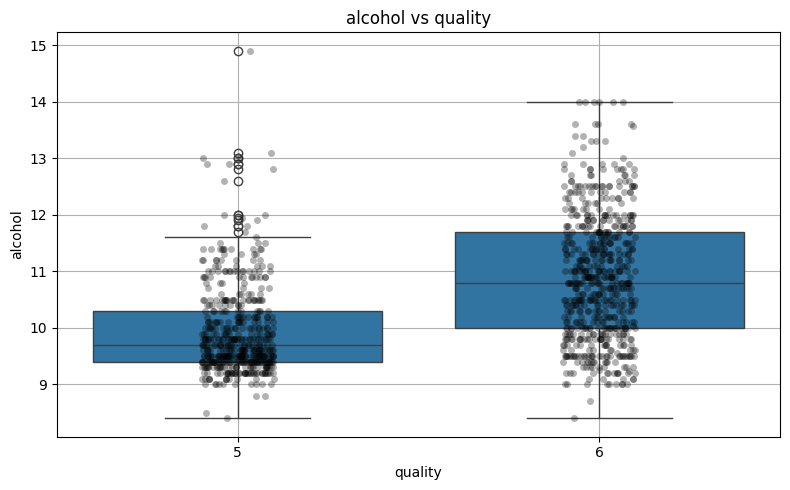


===== FEATURE: sulphates =====

Class 5
count    522.000000
mean       0.614195
std        0.171413
min        0.330000
25%        0.520000
50%        0.570000
75%        0.640000
max        2.000000
Name: sulphates, dtype: float64

Class 6
count    621.000000
mean       0.694283
std        0.160801
min        0.390000
25%        0.590000
50%        0.660000
75%        0.770000
max        1.950000
Name: sulphates, dtype: float64

===== SHAPIRO-WILK =====
Class 5: stat=0.7263, p=0.000000
Class 6: stat=0.8459, p=0.000000

===== LEVENE =====
stat=2.3423, p=0.126178

===== WELCH T-TEST =====
stat=-8.0932, p=0.000000

===== MANN-WHITNEY U =====
stat=94833.0000, p=0.000000

===== CONFIDENCE INTERVAL =====
Mean difference: -0.0801
95% CI: [-0.0995, -0.0607]


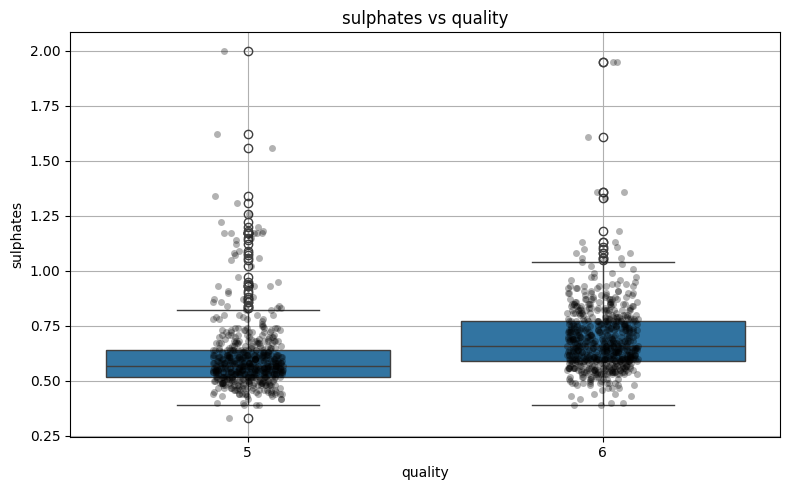


===== FEATURE: volatile acidity =====

Class 5
count    522.000000
mean       0.596121
std        0.179422
min        0.180000
25%        0.470000
50%        0.590000
75%        0.690000
max        1.580000
Name: volatile acidity, dtype: float64

Class 6
count    621.000000
mean       0.476884
std        0.160874
min        0.120000
25%        0.360000
50%        0.470000
75%        0.580000
max        1.040000
Name: volatile acidity, dtype: float64

===== SHAPIRO-WILK =====
Class 5: stat=0.9647, p=0.000000
Class 6: stat=0.9798, p=0.000000

===== LEVENE =====
stat=0.5698, p=0.450501

===== WELCH T-TEST =====
stat=11.7290, p=0.000000

===== MANN-WHITNEY U =====
stat=225110.0000, p=0.000000

===== CONFIDENCE INTERVAL =====
Mean difference: 0.1192
95% CI: [0.0993, 0.1392]


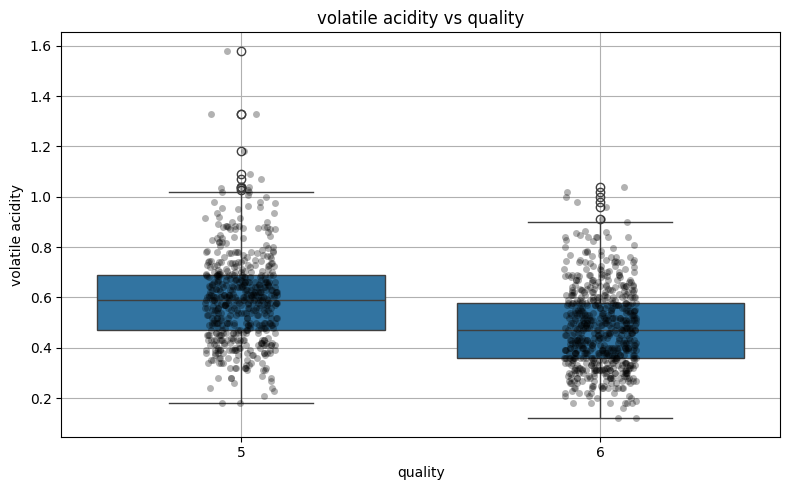

In [4]:
# TESTS

for feature in features:

    compare_feature_between_classes(
        df,
        feature=feature,
        class_a=5,
        class_b=6
    )